In [1]:
import yaml
import numpy as np
import polars as pl
import polars.selectors as cs
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Get gene trait associations
RAP_DIR = 'project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results'

# ASSOC_FILE = 'loftee_mac20_associations_bh_corrected.parquet'
# ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR.parquet'
ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per.parquet'

LOCAL_DIR = '/home/dnanexus/data_dir/'

!dx download {RAP_DIR}/{ASSOC_FILE} -o {LOCAL_DIR}

gene_trait_df = (
    pl.read_parquet(f'{LOCAL_DIR}/{ASSOC_FILE}')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

CORR_FILE = 'regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet'
!dx download {RAP_DIR}/{CORR_FILE} -o {LOCAL_DIR}

loftee_corrs = (
    pl.read_parquet(f'{LOCAL_DIR}/{CORR_FILE}')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    .sort('loftee_corr_abs', descending=True)
    .unique(subset=["region"], keep="first", maintain_order=True)
)
gene_trait_df

Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_
miss20per.parquet" already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_
correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64,f64
"""ENSG00000244734""","""mean_corpuscular_haemoglobin_i…",5.8426e-107,-0.414609,0.414609,-1.0
"""ENSG00000188536""","""mean_corpuscular_haemoglobin_i…",4.2593e-22,-0.366514,0.366514,-1.0
"""ENSG00000101439""","""cystatin_c_int""",9.0570e-172,-0.364046,0.364046,-1.0
"""ENSG00000149948""","""standing_height_int""",0.035047,-0.302164,0.302164,-1.0
"""ENSG00000205846""","""aspartate_aminotransferase_int""",0.049103,0.298817,0.298817,1.0
…,…,…,…,…,…
"""ENSG00000104408""","""mean_corpuscular_volume_int""",0.003124,-0.005248,0.005248,-1.0
"""ENSG00000162992""","""glycated_haemoglobin_hba1c_int""",0.000525,0.004895,0.004895,1.0
"""ENSG00000134030""","""leg_fat_percentage_right_int""",0.028495,0.003606,0.003606,1.0


In [3]:
# Configuration and paths
mac = 20
pheno_list_type = None
# pheno_list_type = 'biochemistry'
# pheno_list_type = 'overall_phenotype'

new_anno_local = None

# Load phenotype configuration
pheno_config_path = "/home/dnanexus/ukbgym/phenotype_config.yaml"
with open(pheno_config_path) as f:
    pheno_config = yaml.safe_load(f)

if pheno_list_type is not None:
    pheno_list = pheno_config[pheno_list_type]

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_odds.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""missense""","""am_pathogenicity""","""#FFCA28""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#FB8C00""","""ESM1v""",-1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
"""conservation""","""gpn_score""","""pink""","""GPN-MSA""",-1
"""conservation""","""verphylop""","""#483D8B""","""Vertebrate PhyloP""",1
…,…,…,…,…
"""regulatory_nondir""","""promoterai_abs""","""#00838F""","""PromoterAI abs""",1
"""regulatory_nondir""","""abexp_abs_max""","""#80CBC4""","""AbExp abs max""",1
"""regulatory_nondir""","""fz_RNA_all_abs_max""","""#FFA500""","""Flashzoi abs max across RNA al…",1


In [4]:
# new_anno_path = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/flashzoi_scores"
# new_anno_filename = "TSS_flashzoi_EURunrelated_variants_burden_test_olink_genes_GENCODEv40_ukbbgym.parquet"
# !dx download {new_anno_path}/{new_anno_filename} -o /home/dnanexus/data_dir/

# new_anno_local = f'/home/dnanexus/data_dir/{new_anno_filename}'

# new_anno_df = (
#     pl.read_parquet(new_anno_local)
#     .filter(pl.col('region').is_in(olink_whitelist['region'].unique()))
#     .with_columns(
#         fz_all_mean = pl.mean_horizontal(cs.starts_with('RNA:').abs()),
#         fz_blood_mean = pl.mean_horizontal(pl.col(['RNA:blood_7531', 'RNA:blood_7532', 'RNA:blood_7533']).abs()),
#     )
#     .select(['id', 'region', 'fz_blood_mean', 'fz_all_mean'])
#     .lazy()
# )

# new_anno_df.head().collect()

In [5]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym.parquet"
ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

min_range = -500
max_range = +500

# Join new annotation if specified above
if new_anno_local is not None:
    anno = (
        anno
        .join(
            new_anno_df,
            on=['id', 'region'],
            how='left'
        )
    )

anno = (
    anno
    .filter(
        # Filter to gene regions of interest
        (pl.col('region').is_in(gene_trait_df['region'].unique())),
        
        # Choose CDS
        # (pl.col('vep_cds_relaxed')==True),

        # Choose non CDS only
        # UPDATE WITH NEW VEP MANE ANNOS
        # ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)),
        
        # Choose Gene Body
        # ((pl.col('consequence_upstream_gene_variant') == False) & (pl.col('consequence_downstream_gene_variant') == False)),

        # Choose VEP consequence
        # (pl.col('consequence_missense_variant') == True),
        # (pl.any_horizontal(cs.contains("consequence_splice") == True)),

        # Core promoter
        # (pl.col('promoterai_is_na') == False),

        # Choose Introns with/without alternate CDS
        # (pl.col('consequence_intron_variant') == True),
        ((pl.col('consequence_intron_variant') == True) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)),

        # Choose pLoF variants
        # (pl.col('loftee_hc') == True),

        # Choose protein domain
        # (pl.col('ted_domain') == True),
        # (pl.col('mobi_curated_disorder_priority') == True),
        # (pl.col('mobi_lip_full') == True),
        # (pl.col('low_complexity_domain') == True),

        # Choose regulatory region
        # (pl.col('not_in_encode') == False),
        # (pl.col('encode_eh_pr') == True),
        # (pl.col('encode_all_tf') == True),

        # Distance to TSS range
        # (pl.col('dist_to_tss') >= min_range),
        # (pl.col('dist_to_tss') <= max_range),

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .with_columns(
        promoterai_abs = pl.col('promoterai').abs(),
    )
)

# selected_categories = ['missense', 'genetic_diversity', 'conservation', 'splicing', 'regulatory_nondir'] # Gene-Body
# selected_categories = ['missense', 'genetic_diversity', 'conservation', 'splicing'] # missense
# selected_categories = ['splicing', 'genetic_diversity', 'conservation'] # splicing
# selected_categories = ['genetic_diversity', 'conservation', 'naive']    # plof comparison
selected_categories = ['genetic_diversity', 'splicing', 'conservation', 'regulatory_nondir'] # non coding
# selected_categories = ['genetic_diversity', 'splicing', 'conservation'] # introns

selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]
selected_annos = list(set(selected_annos).intersection(set(existing_annos)))
fillna_cols = [c+'_is_na' for c in selected_annos]

anno = (
    anno
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )
    .collect(engine='streaming')
)


anno

Error: path
"/home/dnanexus/data_dir/annotations_fillna_ukbgym_with_mane.parquet" already
exists but -f/--overwrite was not set


/tmp/ipykernel_631520/2787006064.py:88: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_631520/2787006064.py:97: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,delta_score,promoterai_abs,pangolin_score,verphylop,cadd_raw,gpn_score,region,absplice2_max,abexp_abs_max,absplice_dna_max
str,f32,f32,f32,f32,f32,f32,str,f32,f32,f32
"""chr8:134702216:A:G""",0.0,0.0,0.0,0.223,0.191705,-0.27,"""ENSG00000066827""",0.000033,0.005598,0.001
"""chr17:49763088:G:A""",0.0,0.0,0.0,1.121,1.054279,-1.25,"""ENSG00000121104""",0.000033,0.013111,0.001
"""chr2:27632492:T:G""",0.01,0.0,0.0,0.527,0.898614,-1.44,"""ENSG00000198522""",0.000033,0.006438,0.000544
"""chr5:128505198:G:A""",0.0,0.0,0.0,0.387,0.344805,0.1,"""ENSG00000138829""",0.000033,0.006871,0.001
"""chr2:171034591:C:G""",0.0,0.0,0.0,0.179,0.025993,0.4,"""ENSG00000198586""",0.000033,0.006189,0.00057
…,…,…,…,…,…,…,…,…,…,…
"""chr11:1761030:A:G""",0.0,0.0,0.0,-0.629,0.271113,1.31,"""ENSG00000117984""",0.000033,0.006286,0.001
"""chr4:183215369:T:C""",0.0,0.0,0.0,0.793,0.71816,-2.38,"""ENSG00000151718""",0.000033,0.006438,0.00057
"""chr1:29034470:T:C""",0.0,0.0,0.0,0.417,0.696483,2.13,"""ENSG00000159023""",0.000033,0.006438,0.001


In [6]:
anno_fillna = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")
fillna_cols = set([c+'_is_na' for c in existing_annos]).intersection(set(anno_fillna.collect_schema().names()))

anno_fillna_melted = (
    anno_fillna
    .filter(pl.col('region').is_in(gene_trait_df['region'].unique()))
    .select(['id', 'region'] + list(fillna_cols))
    .join(
        anno.select(['id', 'region']).lazy(), 
        on=['id', 'region'], 
        how='semi'
    )
    .unpivot(
        index=["id", "region"],
        on=list(fillna_cols),
        variable_name="annotation",
        value_name="annotation_is_na"
    )
    .filter(
        pl.col('annotation_is_na') == 1
    )
    .with_columns(
        annotation = pl.col('annotation').str.replace('_is_na$', '')
    )
    # .collect(engine='streaming')
)

anno_fillna_melted.head().collect()

/tmp/ipykernel_631520/2939847608.py:28: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,annotation,annotation_is_na
str,str,str,i8
"""chr2:143249008:T:A""","""ENSG00000075884""","""delta_score""",1
"""chr11:70887460:G:A""","""ENSG00000162105""","""delta_score""",1
"""chr8:108432898:T:C""","""ENSG00000104408""","""delta_score""",1
"""chr3:51361844:C:A""","""ENSG00000088538""","""delta_score""",1
"""chr6:152128509:C:T""","""ENSG00000131018""","""delta_score""",1


In [7]:
melted_anno = (
    anno.lazy()

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df.select(["annotation", "category", "annotation_dir"]).lazy(),
        on="annotation",
        how="left"
    )
    .filter(pl.col('category').is_in(selected_categories))
    .unique()

    # Remove null annotation scores
    .drop_nulls('annotation_score')

    # Keep variants that don't have fillna annotation
    .join(
        anno_fillna_melted,
        on=['id', 'region', 'annotation'],
        how='anti'
    )

    # Correct scores by annotation direction
    .with_columns(
        annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir").cast(pl.Float32)
    )
    
    # Implement filtering based on the defined percentile
    .with_columns(
        annotation_score_dircor_rank_desc = pl.col('annotation_score_dircor').rank(method="max", descending=True).over(["annotation"]).cast(pl.Float32)
    )
    .drop(['annotation_score_dircor'])

    .collect(engine='streaming')
)

melted_anno

/tmp/ipykernel_631520/315562140.py:45: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,annotation,annotation_score,category,annotation_dir,annotation_score_dircor_rank_desc
str,str,str,f32,str,i8,f32
"""chr2:124611221:G:C""","""ENSG00000155052""","""gpn_score""",-1.5,"""conservation""",-1,5.522896e6
"""chr11:100745113:T:C""","""ENSG00000165895""","""gpn_score""",-1.91,"""conservation""",-1,3.177845e6
"""chr4:2632754:G:C""","""ENSG00000125386""","""gpn_score""",-1.55,"""conservation""",-1,4.916982e6
"""chr2:233753396:G:C""","""ENSG00000242515""","""gpn_score""",-0.05,"""conservation""",-1,1.2812211e7
"""chr5:69269759:T:G""","""ENSG00000134058""","""gpn_score""",-0.89,"""conservation""",-1,1.0220267e7
…,…,…,…,…,…,…
"""chr15:101442335:T:C""","""ENSG00000140479""","""gpn_score""",-1.36,"""conservation""",-1,7.350413e6
"""chr1:10244592:C:A""","""ENSG00000054523""","""gpn_score""",-1.51,"""conservation""",-1,5.386223e6
"""chr2:182496520:G:T""","""ENSG00000115252""","""gpn_score""",-3.72,"""conservation""",-1,931903.0


In [8]:
anno['region'].value_counts(sort=True).filter(pl.col('count')>=50)

region,count
str,u64
"""ENSG00000169855""",265082
"""ENSG00000130226""",230674
"""ENSG00000048052""",229311
"""ENSG00000155052""",209840
"""ENSG00000169862""",209732
…,…
"""ENSG00000204420""",217
"""ENSG00000092067""",217
"""ENSG00000197191""",107


In [9]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus/data_dir"

# APPV_FILE = "loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet"
APPV_FILE = "quant_pheno_loftee_mac20_EURunrelated_miss20per_appv_percentiles_small.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value_ptile', 'n_individuals']
    )
)
# unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()

Error: path "/home/dnanexus/data_dir/quant_pheno_loftee_mac20_EURunrelated_mis
s20per_appv_percentiles_small.parquet" already exists but -f/--overwrite was
not set


## Odds ratio computation

In [10]:
n_steps = 101
min_rank_cutoff = 1_0
max_rank_cutoff = 10_000_000
max_rank_cutoff = np.min([max_rank_cutoff, anno.shape[0]])
or_threshold_pheno = 0.99

# We assume that all models score the same number of variants (all the variants in 'anno')
log_steps = np.geomspace(min_rank_cutoff, max_rank_cutoff, n_steps)

# Prepare cutoffs once
cutoffs_sorted = (
    pl.LazyFrame({"rank_cutoff": log_steps.astype(int)})
    .with_columns(pl.col('rank_cutoff').cast(pl.Float32))
    .sort('rank_cutoff')
    .collect()
)

cutoffs_sorted

rank_cutoff
f32
10.0
11.0
13.0
15.0
17.0
…
5.754399e6
6.606934e6
7.585775e6


In [11]:
id_region = anno.select(['id', 'region']).unique().lazy()

# Stream-collect base data ONCE: ~18M rows × 3 cols (small)
gp_base = (
    appv
    .join(id_region, on='id', how='inner')
    .join(gene_trait_df.lazy(), on=['region', 'phenotype'], how='inner')
    .with_columns(
        is_extreme = (
            pl.when(pl.col('loftee_corr_dir') == -1)
                .then(1 - pl.col('mean_pheno_value_ptile'))
                .otherwise(pl.col('mean_pheno_value_ptile'))
            >= or_threshold_pheno
        )
    )
    .select(['id', 'region', 'is_extreme'])
    .collect(engine='streaming')
)

# Process one annotation at a time — peak RAM is ~1 annotation's worth
results = []
for annotation in tqdm(melted_anno['annotation'].unique().sort()):
    anno_ranks = (
        melted_anno
        .filter(pl.col('annotation') == annotation)
        .select(['id', 'region', 'annotation_score_dircor_rank_desc'])
    )

    rank_counts = (
        gp_base.lazy()
        .join(anno_ranks.lazy(), on=['id', 'region'], how='inner')
        .group_by('annotation_score_dircor_rank_desc')
        .agg(
            n_extreme = pl.col('is_extreme').sum().cast(pl.Int64),
            n_total = pl.len().cast(pl.Int64),
        )
        .collect()
        .sort('annotation_score_dircor_rank_desc')
        .with_columns(
            cum_extreme = pl.col('n_extreme').cum_sum(),
            cum_total = pl.col('n_total').cum_sum(),
        )
    )

    total_extreme = rank_counts['n_extreme'].sum()
    total_count = rank_counts['n_total'].sum()

    result = (
        cutoffs_sorted
        .join_asof(
            rank_counts,
            left_on='rank_cutoff',
            right_on='annotation_score_dircor_rank_desc',
            strategy='backward',
        )
        .with_columns(
            cum_extreme = pl.col('cum_extreme').fill_null(0),
            cum_total = pl.col('cum_total').fill_null(0),
        )
        .with_columns(
            annotation = pl.lit(annotation),
            n_dis_above = pl.col('cum_extreme'),
            n_notdis_above = pl.col('cum_total') - pl.col('cum_extreme'),
            n_dis_below = pl.lit(total_extreme) - pl.col('cum_extreme'),
            n_notdis_below = pl.lit(total_count - total_extreme)
                           - (pl.col('cum_total') - pl.col('cum_extreme')),
        )
        .select(['annotation', 'rank_cutoff', 'n_dis_above', 'n_notdis_above',
                 'n_dis_below', 'n_notdis_below'])
    )
    results.append(result)

# Combine (11 × 101 = 1,111 rows) and compute OR + CI
or_df = (
    pl.concat(results)
    .with_columns(
        odds_ratio = (pl.col('n_dis_above') / pl.col('n_notdis_above'))
                   / (pl.col('n_dis_below') / pl.col('n_notdis_below'))
    )
    .filter(pl.col('odds_ratio').is_finite() & (pl.col('odds_ratio') > 0))
    .with_columns(
        se_log_or = (
            1/pl.col('n_dis_above').cast(pl.Float64)
            + 1/pl.col('n_notdis_above').cast(pl.Float64)
            + 1/pl.col('n_dis_below').cast(pl.Float64)
            + 1/pl.col('n_notdis_below').cast(pl.Float64)
        ).sqrt(),
    )
    .with_columns(
        ci_lower = (pl.col('odds_ratio').cast(pl.Float64).log() - 1.96 * pl.col('se_log_or')).exp(),
        ci_upper = (pl.col('odds_ratio').cast(pl.Float64).log() + 1.96 * pl.col('se_log_or')).exp(),
    )
    .sort('rank_cutoff', descending=True)
)

or_df


100%|██████████| 9/9 [00:28<00:00,  3.15s/it]


annotation,rank_cutoff,n_dis_above,n_notdis_above,n_dis_below,n_notdis_below,odds_ratio,se_log_or,ci_lower,ci_upper
str,f32,i64,i64,i64,i64,f64,f64,f64,f64
"""abexp_abs_max""",1e7,69368,6783329,68243,6905729,1.034827,0.005419,1.023895,1.045876
"""absplice2_max""",1e7,20082,1979126,86703,8631447,1.010143,0.007871,0.99468,1.025848
"""absplice_dna_max""",1e7,10148,993952,87811,8762404,1.018801,0.010538,0.997974,1.040063
"""cadd_raw""",1e7,90201,8792704,50087,5159187,1.056684,0.0056,1.045149,1.068346
"""delta_score""",1e7,6949,661687,90624,9052314,1.049026,0.012512,1.023612,1.07507
…,…,…,…,…,…,…,…,…,…
"""absplice_dna_max""",11.0,2,8,97957,9756348,24.899568,0.790576,5.287374,117.258312
"""pangolin_score""",11.0,1,8,106784,10610565,12.420593,1.060665,1.553411,99.311216
"""absplice2_max""",10.0,1,9,106784,10610564,11.040526,1.054097,1.398699,87.147572


## Plotting

In [12]:
print('unique percentile cutoffs:', or_df['rank_cutoff'].n_unique())

plt_df = (
    or_df
    .drop_nans()
    .filter(pl.col("odds_ratio").is_finite())
    .with_columns(
        # n_gene_phenos = pl.len().over(['rank_cutoff', 'annotation']),
        log_rank_cutoff = pl.col('rank_cutoff').log10(),
        log_rank_cutoff_inv = (1 / pl.col('rank_cutoff')).log10(),
    )
    .join(
        anno_config_df.select(['annotation', 'color', 'label', 'category']),
        on='annotation',
        how='left'
    )
    .filter(pl.col('category').is_in(selected_categories))
    .sort('log_rank_cutoff')
    
    # Remove shaky data points
    .filter(
        (pl.col('n_dis_above')>5),
        (pl.col('n_dis_below')>5),
        (pl.col('n_notdis_above')>5),
        (pl.col('n_notdis_below')>5),
    )
)

plt_df

unique percentile cutoffs: 101


annotation,rank_cutoff,n_dis_above,n_notdis_above,n_dis_below,n_notdis_below,odds_ratio,se_log_or,ci_lower,ci_upper,log_rank_cutoff,log_rank_cutoff_inv,color,label,category
str,f32,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,str,str,str
"""absplice2_max""",69.0,6,59,106779,10610514,10.105314,0.428515,4.363051,23.405036,1.838849,-1.838849,"""#2E7D32""","""AbSplice2 (max)""","""splicing"""
"""absplice2_max""",79.0,6,69,106779,10610504,8.640768,0.425639,3.751809,19.900495,1.897627,-1.897627,"""#2E7D32""","""AbSplice2 (max)""","""splicing"""
"""absplice2_max""",91.0,7,80,106778,10610493,8.694845,0.394166,4.015515,18.827058,1.959041,-1.959041,"""#2E7D32""","""AbSplice2 (max)""","""splicing"""
"""absplice2_max""",104.0,9,91,106776,10610482,9.827942,0.349442,4.954635,19.494561,2.017033,-2.017033,"""#2E7D32""","""AbSplice2 (max)""","""splicing"""
"""absplice_dna_max""",104.0,6,90,97953,9756266,6.6401,0.421649,2.905759,15.173638,2.017033,-2.017033,"""#26C6DA""","""AbSplice (max)""","""splicing"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""delta_score""",1e7,6949,661687,90624,9052314,1.049026,0.012512,1.023612,1.07507,7.0,-7.0,"""#00838F""","""SpliceAI""","""splicing"""
"""gpn_score""",1e7,93289,8883516,46998,5068332,1.132482,0.005684,1.119935,1.145169,7.0,-7.0,"""pink""","""GPN-MSA""","""conservation"""
"""pangolin_score""",1e7,12935,1262760,93850,9347813,1.020285,0.009427,1.001607,1.039311,7.0,-7.0,"""#8BC34A""","""Pangolin""","""splicing"""


dxpy.utils.resolver.ResolutionError: Unable to resolve "category_or_reference_points.parquet" to a data object or folder name in '/processed_data/ukbgym/odds_ratio_results'


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/geoms/annotation_logticks.py:97: PlotnineWarning: annotation_logticks for x-axis which does not have a log scale. The logticks may not make sense.


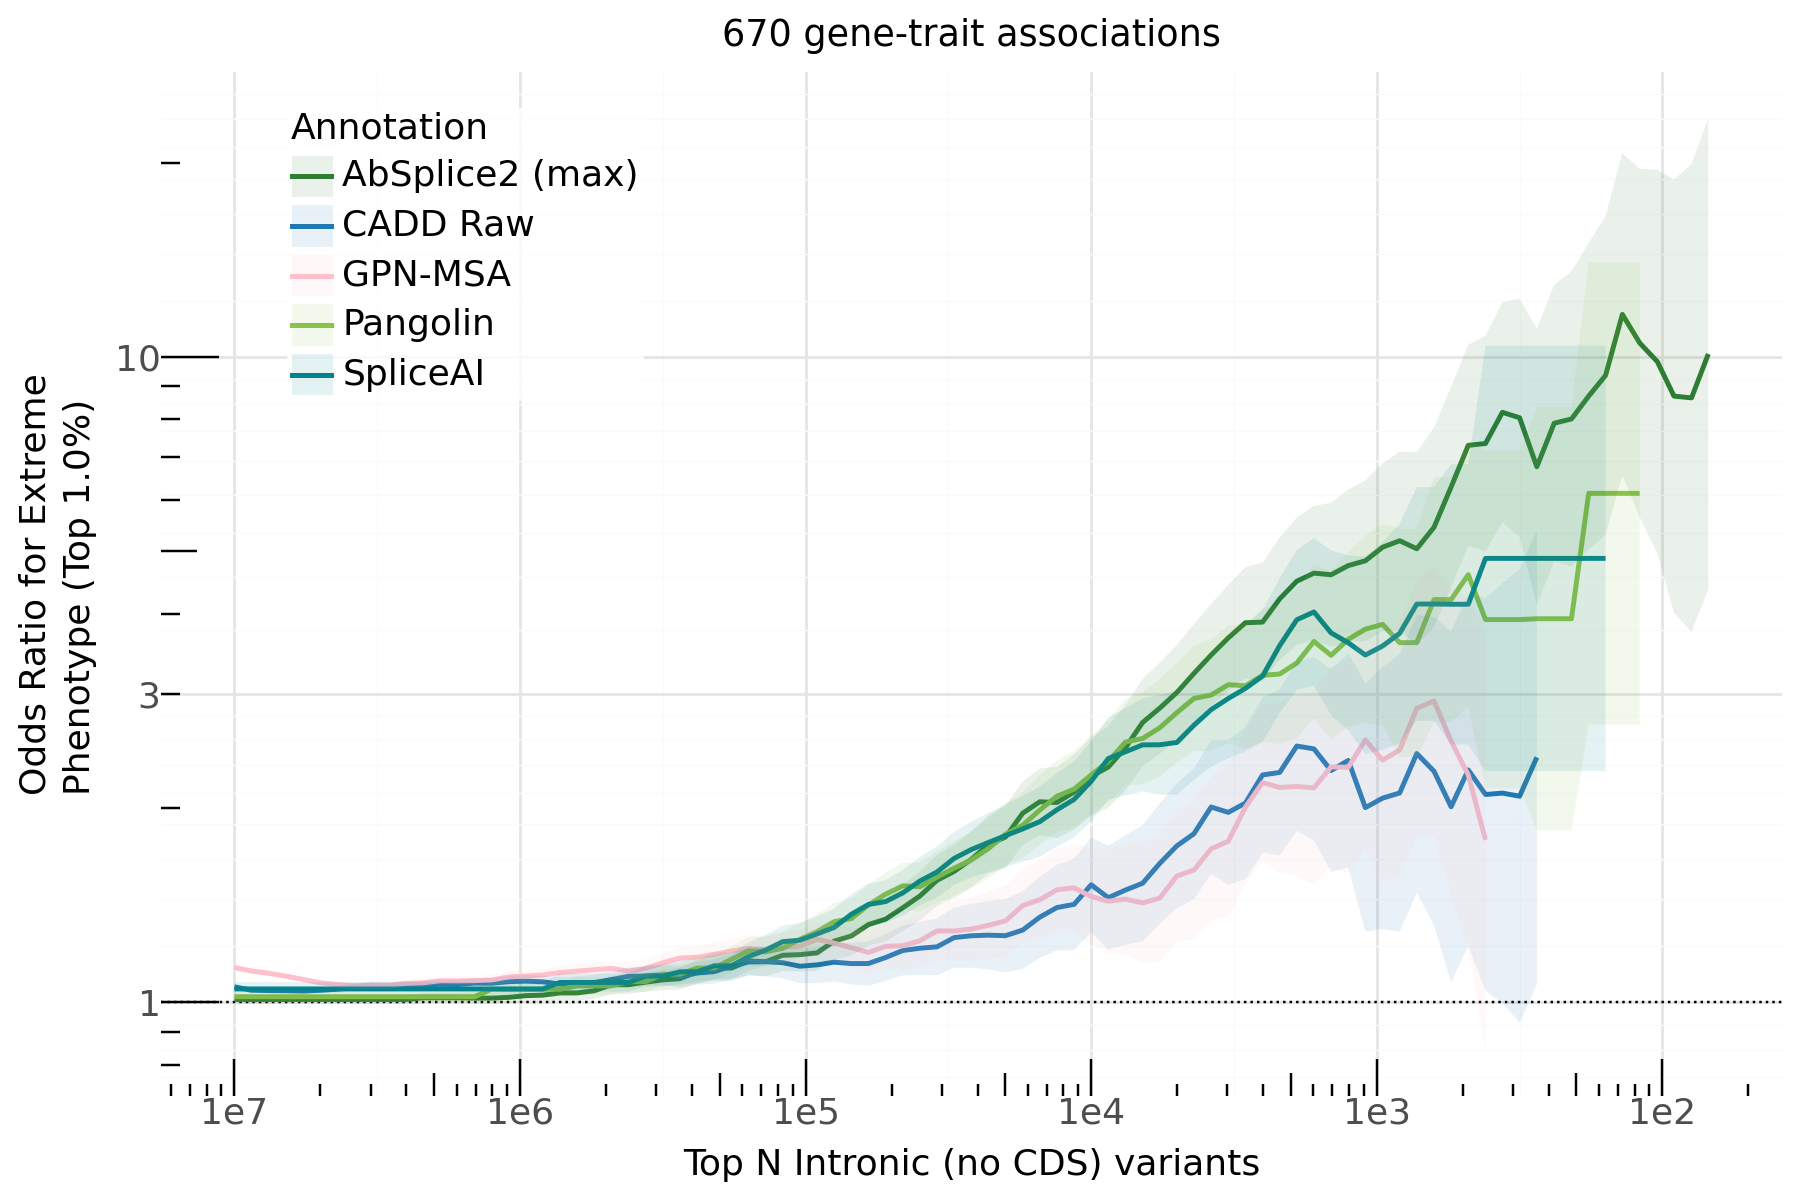

In [14]:
plot_df = (
    plt_df
    .filter(
        # (pl.col('log_rank_cutoff_inv') >= -5.5),
        # (pl.col('log_rank_cutoff_inv') <= -3),

        # (pl.col('annotation').is_in(['am_pathogenicity', 'gpn_score', 'absplice2_max']))
        # (pl.col('annotation').is_in(['am_pathogenicity', 'gpn_score', 'absplice2_max', 'abexp_abs_max', 'cadd_raw']))
        # (pl.col('annotation').is_in(['am_pathogenicity', 'esmscoremissense', 'gpn_score']))
        (pl.col('annotation').is_in(['gpn_score', 'cadd_raw', 'pangolin_score', 'delta_score', 'absplice2_max']))
        # (pl.col('annotation').is_in(['gpn_score', 'cadd_raw', 'promoterai_abs', 'fz_RNA_blood_abs_max', 'fz_RNA_all_abs_max']))
        # (pl.col('annotation').is_in(['gpn_score', 'cadd_raw', 'promoterai_abs', 'abexp_abs_max']))
    )
)

# Generate breaks and labels for x-axis
start_exp = int(np.log10(1/max_rank_cutoff))
end_exp = int(np.log10(1/min_rank_cutoff))
breaks_linear = np.arange(start_exp, end_exp + 1)
labels_sci = [f"1e{-b}" for b in breaks_linear]

color_dict = dict(zip(plt_df['label'], plt_df['color']))
pheno_label = round((1 - or_threshold_pheno) * 100, 1)


# Load reference OR point from categories notebook
RAP_REF_OR = 'project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/odds_ratio_results'
ref_or_local = f'{LOCAL_APPV_DIR}/category_or_reference_points.parquet'
!dx download {RAP_REF_OR}/category_or_reference_points.parquet -o {ref_or_local} -f

ref_annotation = 'loftee_hc'
ref_region = 'Gene body'

ref_point = (
    pl.read_parquet(ref_or_local)
    .filter(
        (pl.col('annotation') == ref_annotation),
        (pl.col('variant_filter') == ref_region),
    )
    .sort((pl.col('pheno_cutoff').cast(pl.Float64) - or_threshold_pheno).abs())
    .head(1)
    .with_columns(
        n_vars = -pl.col('n_variants').cast(pl.Float64).log() / np.log(10),
        mean_or = pl.col('odds_ratio'),
        ci_low_pheno = pl.col('ci_lower'),
        ci_high_pheno = pl.col('ci_upper'),
        label = pl.lit(ref_annotation),
    )
)

loftee_point = [] if ref_point.is_empty() else [
    geom_point(ref_point, aes(x='n_vars', y='mean_or'), color='black', size=2),
    geom_errorbar(ref_point, aes(x='n_vars', y='mean_or', ymin='ci_low_pheno', ymax='ci_high_pheno'), width=0.01),
    geom_text(ref_point, aes(x='n_vars', y='mean_or', label='label'), nudge_x=-0.1, size=13, ha='right'),
]

(
    ggplot(
        plot_df,
        aes(x='log_rank_cutoff_inv', y='odds_ratio')
    )
    + geom_hline(aes(yintercept=1), color='black', linetype='dotted')
    + geom_line(aes(color='label'), size=1)
    + geom_ribbon(aes(ymin='ci_lower', ymax='ci_upper', fill='label'), alpha=0.1)
    + loftee_point
    + scale_fill_manual(values=color_dict)
    + scale_color_manual(values=color_dict)
    + labs(
        title=f"{gene_trait_df.shape[0]} gene-trait associations",
        y=f"Odds Ratio for Extreme\nPhenotype (Top {pheno_label}%)",
        x=f"Top N Intronic (no CDS) variants",
        color="Annotation",
        fill="Annotation",
    )
    + scale_x_continuous(
        breaks=breaks_linear,
        labels=labels_sci
    )
    + scale_y_log10()
    + annotation_logticks(sides="lb")
    + theme_minimal()
    + theme(
        figure_size=(9, 6),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13, lineheight=1.4),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        legend_position=(0.1, 0.95), 
        legend_background=element_rect(fill="white", color='white', alpha=0.8),
        plot_background=element_rect(fill="white", color="white"),
    )
)